In [4]:
import pymrio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
# Load the original EXIOBASE data
exio3 = pymrio.parse_exiobase3(
    path=r"C:\Users\Dyde-nairn\Documents\python\_input_output_dependencies\IOT_2022_pxp.v3.8.2.zip"
)


In [11]:

# Compute Leontief inverse manually
exio3.L = pymrio.calc_L(exio3.A)


In [12]:
sector_name = "Aluminium ores and concentrates"
countries = exio3.A.columns.get_level_values(0).unique()

In [18]:
# Compute original Leontief inverse
exio3.L = pymrio.calc_L(exio3.A)

# Original output for French wind energy
original_output = exio3.L @ exio3.Y.sum(axis=1)
original_fr_wind = original_output.loc[("FR", "Electricity by wind")]

# Apply 1% productivity shock to Aluminium ores and concentrates in Australia
country = "AU"
sector_name = "Aluminium ores and concentrates"

shocked_A = exio3.A.copy()
shocked_A.loc[:, (country, sector_name)] *= 1 / (1 - 0.01)  # Scale column by ~1.0101

# Compute new Leontief inverse and shocked output
shocked_L = pymrio.calc_L(shocked_A)
shocked_output = shocked_L @ exio3.Y.sum(axis=1)
shocked_fr_wind = shocked_output.loc[("FR", "Electricity by wind")]

# Print impact
impact = shocked_fr_wind - original_fr_wind
print(f"Impact on French wind energy after 1% productivity shock in {sector_name} ({country}): {impact:.6f} EUR")

Impact on French wind energy after 1% productivity shock in Aluminium ores and concentrates (AU): 0.000010 EUR


In [ ]:

# Compute original Leontief inverse
exio3.L = pymrio.calc_L(exio3.A)

# -----------------------------
# Step 2: Original French wind output
# -----------------------------
original_output = exio3.L @ exio3.Y.sum(axis=1)
original_fr_wind = original_output.loc[("FR", "Electricity by wind")]

# -----------------------------
# Step 3: Define sector and countries
# -----------------------------
sector_name = "Aluminium ores and concentrates"
countries = exio3.A.columns.get_level_values(0).unique()

# Dictionary to store percentage impact results
impact_percent = {}

# -----------------------------
# Step 4: Loop over countries and apply shock
# -----------------------------
for country in countries:
    shocked_A = exio3.A.copy()
    shocked_A.loc[:, (country, sector_name)] *= (1 - 0.01) 
    shocked_L = pymrio.calc_L(shocked_A)
    shocked_output = shocked_L @ exio3.Y.sum(axis=1)
    shocked_fr_wind = shocked_output.loc[("FR", "Electricity by wind")]
    impact = shocked_fr_wind - original_fr_wind
    impact_percent[country] = (impact / original_fr_wind) * 100  # Convert to %

# -----------------------------
# Step 5: Create DataFrame and plot
# -----------------------------
impact_df = pd.DataFrame({
    "Country": list(impact_percent.keys()),
    "Impact (%)": list(impact_percent.values())
}).sort_values(by="Impact (%)", ascending=False)

# Plot the results
plt.figure(figsize=(14, 8))
plt.barh(impact_df["Country"], impact_df["Impact (%)"], color='blue')
plt.title("Impact on French Wind Energy Output (%) by 1% Productivity Shock in Aluminium Ore (per Country)")
plt.xlabel("Percentage Change in Output")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("impact_fr_wind_aluminium_ores_percent.png", dpi=300)
plt.show()


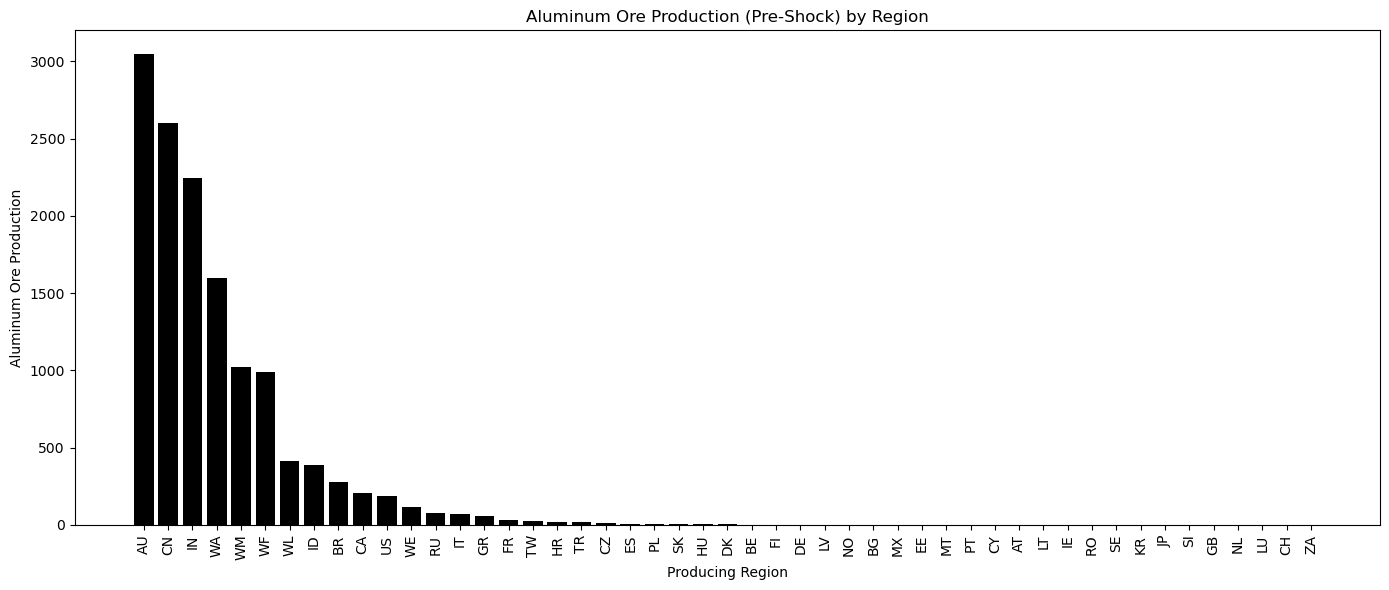

In [8]:
# Use IndexSlice for MultiIndex selection
idx = pd.IndexSlice
sector_name = "Aluminium ores and concentrates"

# Extract gross output for Aluminum Ore by country
aluminium_output = exio3.x.loc[idx[:, sector_name], :]
aluminium_output_df = aluminium_output.reset_index()
aluminium_output_df.columns = ["Country", "Sector", "Output"]

# Sort by output
aluminium_output_df = aluminium_output_df.sort_values(by="Output", ascending=False)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(aluminium_output_df["Country"], aluminium_output_df["Output"], color="black")
plt.title("Aluminum Ore Production (Pre-Shock) by Region")
plt.ylabel("Aluminum Ore Production")
plt.xlabel("Producing Region")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("aluminium_production_by_region.png", dpi=300)
plt.show()